# TITLE

 House Price Prediction using Linear Regression

Problem Predict house prices based on features like area, bedrooms, bathrooms...

# 1-Import Libraries

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 2-Load Data

In [179]:
data=pd.read_csv('Housing.csv')
data.head()



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [180]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# 3-Data Cleaning

In [181]:
print(data.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [182]:
print(data.duplicated().sum())

0


In [183]:

le=LabelEncoder()
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']

for col in binary_cols:
    data[col] = data[col].astype(str).str.strip().str.lower()
    data[col] = data[col].map({'yes': 1, 'no': 0})


data['furnishingstatus']=le.fit_transform(data['furnishingstatus'])
data



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,2
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,2
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0


# 4-Exploratory Data Analysis

(array([ 61., 163., 139.,  89.,  46.,  25.,  13.,   4.,   1.,   4.]),
 array([ 1750000.,  2905000.,  4060000.,  5215000.,  6370000.,  7525000.,
         8680000.,  9835000., 10990000., 12145000., 13300000.]),
 <BarContainer object of 10 artists>)

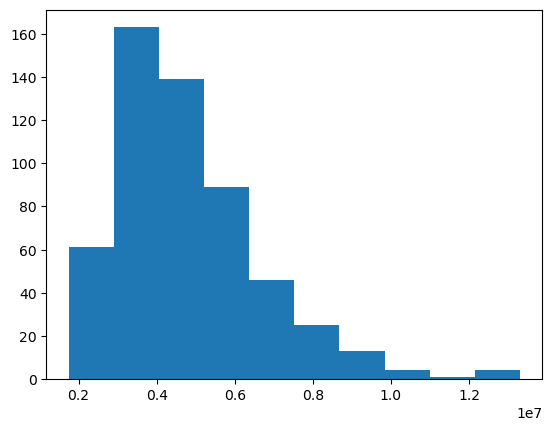

In [184]:
plt.hist(data['price'])


price               1.000000
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
furnishingstatus   -0.304721
Name: price, dtype: float64


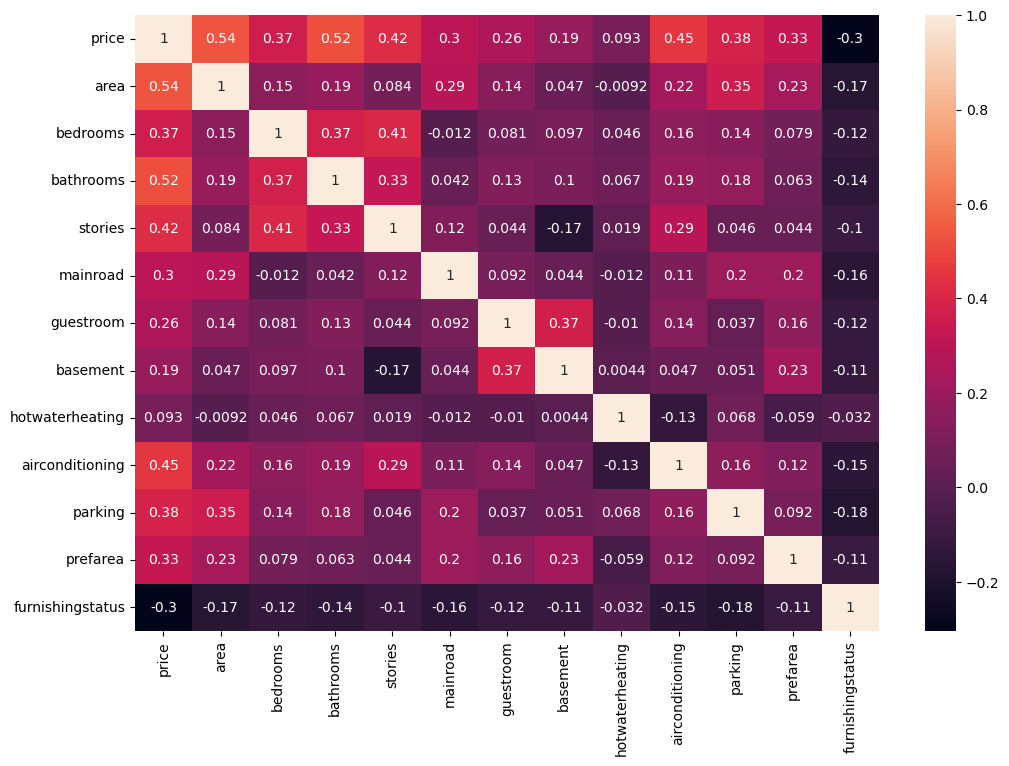

In [185]:
corr=data.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True)
print(corr['price'].sort_values(ascending=False))


# 5-Feature Selection

In [186]:
features = ['area', 'bathrooms', 'airconditioning', 'stories', 'parking', 'bedrooms']

X = data[features]
y = data['price']

# 6-split and scaled the data

In [187]:

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [188]:


scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 7-model training

In [189]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train_scaled,y_train)


LinearRegression()

In [190]:
predict=model.predict(x_test_scaled)
predict

array([5203691.70963177, 7257004.02115475, 3062828.59668172,
       4559591.65374424, 3332932.30559783, 3563080.67918996,
       5645466.3121997 , 6413979.66873635, 2755831.54819001,
       2668938.6607523 , 9570600.29915351, 2827431.50860062,
       3195686.25834091, 3352263.99438472, 3713879.49996132,
       5301088.2443575 , 2987920.26669682, 4810799.8212371 ,
       4383031.70489929, 3525092.18938646, 5796259.50068013,
       5840000.702993  , 2760214.60864101, 4762590.14920608,
       5204755.73895204, 7515542.71619022, 3254681.68956383,
       5236164.45964445, 8178523.1682028 , 3434166.1567565 ,
       6443921.58767582, 3346004.77919185, 6742324.74004132,
       4154936.84088665, 3589152.47491253, 5788125.92515323,
       4768370.18154077, 4391684.04193173, 3217657.04549936,
       4638196.61928879, 4522160.27786713, 3541284.06127246,
       7238136.1194117 , 4021515.68926614, 3701978.76822756,
       4298879.55563098, 6705004.0206061 , 3993466.52296897,
       3798185.05328058,

# 8-Evaluation

In [191]:


y_pred = model.predict(x_test_scaled)

r2 = r2_score(y_test, predict)

print("R2 Score =", r2)

R2 Score = 0.6494754192267793


# 9-Conclusion

In this project, a Linear Regression model was developed to predict house prices based on several key features such as area, number of bedrooms, 
bathrooms, and other property characteristics. The dataset was carefully cleaned and preprocessed, including encoding categorical variables and
handling binary features to ensure compatibility with the model. Exploratory Data Analysis revealed that features like area and bathrooms have 
the strongest positive correlation with house prices, while some other features showed weaker relationships with the target variable.
After training and evaluating the model, it achieved an R² score of approximately 0.65, indicating that the model explains around 65% of 
the variance in house prices. This suggests that while the model captures the general trend in the data, there is still room for improvement. 
Future enhancements could include feature engineering, removing irrelevant features, and experimenting with more advanced models such as 
Random Forest or Gradient Boosting to improve predictive performance.